# 📊 Análise de Churn com Pandas: Identificando Padrões e Estratégias

**Autor:** Juliana Bernardino | JB Data Insights

## Introdução

Este projeto realiza uma **Análise Exploratória de Dados (EDA)** sobre o *Churn* (cancelamento) de clientes em um serviço de telecomunicações. O objetivo é identificar padrões de comportamento, entender as causas que levam os clientes ao cancelamento e fornecer *insights* estratégicos para a retenção. O conjunto de dados contém informações demográficas, de uso, financeiras e de satisfação do cliente.

## 1. Configuração e Importações

Importação das bibliotecas necessárias para a análise e configuração inicial do ambiente.

In [6]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dataset_churn_100_linhas.csv")
df.head()
import matplotlib.pyplot as plt
from cycler import cycler

rosa = "#C77AA0"
azul_escuro = "#132845"
branco = "#F3F4F5"

plt.rcParams.update({
    "axes.facecolor": azul_escuro,
    "figure.facecolor": azul_escuro,
    "axes.edgecolor": branco,
    "axes.labelcolor": branco,
    "xtick.color": branco,
    "ytick.color": branco,
    "text.color": branco,
    "axes.titlecolor": branco,

    "axes.prop_cycle": cycler(color=[rosa, branco]),

    "grid.color": branco,
    "grid.alpha": 0.1
})

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset_churn_100_linhas.csv'

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Carregamento e Visão Geral dos Dados

Carregamento do conjunto de dados e inspeção inicial para verificar a estrutura e as primeiras linhas.

In [5]:
df.head()

NameError: name 'df' is not defined

## 3. Análise Exploratória de Dados (EDA)Nesta seção, exploramos as variáveis para identificar padrões e correlações com a variável alvo (*churn*).

In [ ]:
df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,65.0
1,35.0


In [ ]:
df.groupby("subscription_length_months")["churn"].mean()


,churn
subscription_length_months,
1,0.000000
2,0.400000
3,0.500000
4,0.000000
5,0.333333
6,1.000000
7,0.666667
9,0.166667
10,0.666667


In [ ]:
(
    df.groupby("subscription_length_months")["churn"]
    .mean()
    .apply(lambda x: f"{x*100:.2f}%")
)

,churn
subscription_length_months,
1,0.00%
2,40.00%
3,50.00%
4,0.00%
5,33.33%
6,100.00%
7,66.67%
9,16.67%
10,66.67%


In [ ]:
top5_subscription_churn = (
    df.groupby("subscription_length_months")["churn"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .round(2)
    .apply(lambda x: f"{x*100:.2f}%")
)

top5_subscription_churn

,churn
subscription_length_months,
6,100.00%
31,100.00%
30,100.00%
23,80.00%
20,67.00%


### 3.3. Análise Geográfica: Estados com Maior Churn

In [ ]:
top5_estado_churn = (
    df.groupby("region")["churn"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .round(2)
    .apply(lambda x: f"{x*100:.2f}%")
)

top5_estado_churn

,churn
region,
BA,50.00%
RS,44.00%
PE,43.00%
SC,40.00%
MG,38.00%


**Insight:** *[Insira aqui o insight principal extraído desta análise, por exemplo: 'Clientes com satisfação 1 e 2 apresentam as maiores taxas de churn.']*

### 3.2. Churn por Nível de Satisfação

In [ ]:
churn_por_satisfacao = (
    df.groupby("customer_satisfaction")["churn"]
    .mean()
    .round(2)
)

churn_por_satisfacao

,churn
customer_satisfaction,
1,0.58
2,0.59
3,0.08
4,0.19
5,0.29


**Insight:** *[Insira aqui o insight principal extraído desta análise, por exemplo: 'Clientes com satisfação 1 e 2 apresentam as maiores taxas de churn.']*

In [ ]:
df.groupby("customer_satisfaction")["churn"].mean().sort_values(ascending=False).head(5)

,churn
customer_satisfaction,
2,0.588235
1,0.576923
5,0.294118
4,0.187500
3,0.083333


### 3.4. Churn por Faixa Etária

In [ ]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ["18-25","26-35","36-45","46-55","56-65","+65"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

df.groupby("age_group")["churn"].mean().sort_values(ascending=False)

/tmp/ipython-input-2798314358.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["churn"].mean().sort_values(ascending=False)


,churn
age_group,
+65,0.714286
56-65,0.545455
26-35,0.400000
36-45,0.217391
18-25,0.200000
46-55,0.153846


**Insight:** *[Insira aqui o insight principal extraído desta análise, por exemplo: 'Clientes com satisfação 1 e 2 apresentam as maiores taxas de churn.']*

### 3.7. Churn por Tipo de Contrato

In [ ]:
df.groupby("contract_type")["churn"].mean().sort_values(ascending=False)

,churn
contract_type,
Mensal,0.380282
Anual,0.275862


**Insight:** *[Insira aqui o insight principal extraído desta análise, por exemplo: 'Clientes com satisfação 1 e 2 apresentam as maiores taxas de churn.']*

In [ ]:
df.corr(numeric_only=True)["churn"].sort_values(ascending=False)

,churn
churn,1.000000
total_tickets,0.255655
age,0.255533
late_payments,0.205774
monthly_fee,0.041655
avg_ticket_resolution_time,0.041253
monthly_calls,0.038293
subscription_length_months,-0.058013
discount_received,-0.163550
monthly_usage_hours,-0.226709


### 3.1. Distribuição Geral de Churn

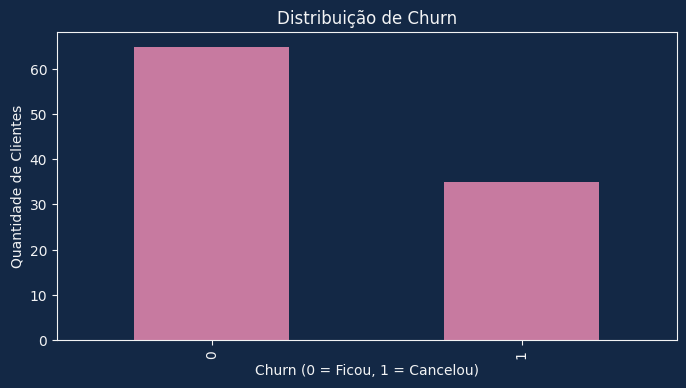

In [ ]:
plt.figure(figsize=(8,4))

df['churn'].value_counts().plot(kind='bar')

plt.title("Distribuição de Churn")
plt.xlabel("Churn (0 = Ficou, 1 = Cancelou)")
plt.ylabel("Quantidade de Clientes")

plt.show()

**Insight:** *[Insira aqui o insight principal extraído desta análise, por exemplo: 'Clientes com satisfação 1 e 2 apresentam as maiores taxas de churn.']*

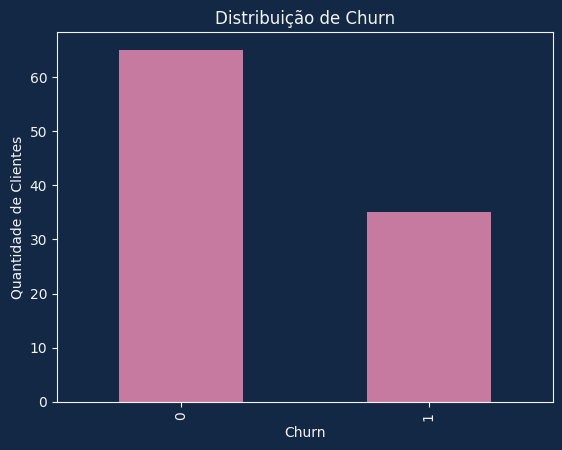

In [ ]:
df['churn'].value_counts().plot(kind='bar')
plt.title("Distribuição de Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de Clientes")
plt.show()

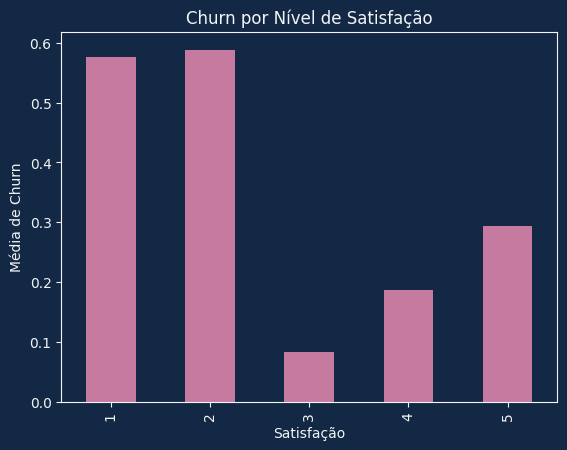

In [ ]:
df.groupby("customer_satisfaction")["churn"].mean().plot(kind='bar')
plt.title("Churn por Nível de Satisfação")
plt.xlabel("Satisfação")
plt.ylabel("Média de Churn")
plt.show()

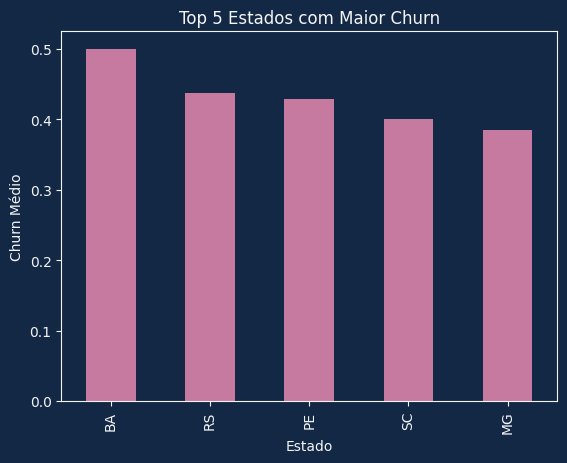

In [ ]:
df.groupby("region")["churn"].mean().sort_values(ascending=False).head(5).plot(kind='bar')
plt.title("Top 5 Estados com Maior Churn")
plt.xlabel("Estado")
plt.ylabel("Churn Médio")
plt.show()

### 3.6. Impacto do Suporte (Tickets)

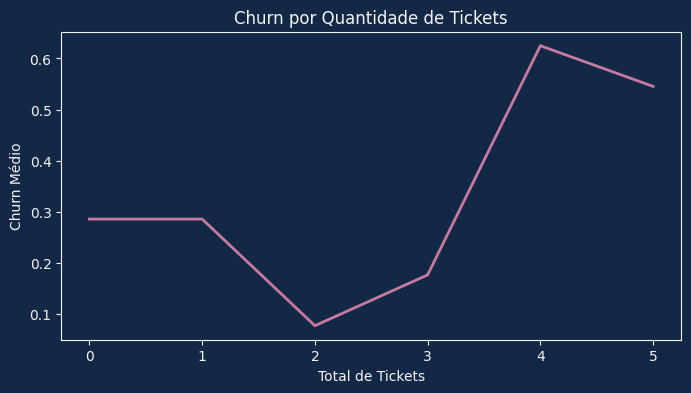

In [ ]:
plt.figure(figsize=(8,4))

# Nenhuma cor definida aqui — ele usa sua paleta automaticamente
plt.plot(
    df.groupby("total_tickets")["churn"].mean(),
    linewidth=2
)

plt.title("Churn por Quantidade de Tickets")
plt.xlabel("Total de Tickets")
plt.ylabel("Churn Médio")

plt.show()

**Insight:** *[Insira aqui o insight principal extraído desta análise, por exemplo: 'Clientes com satisfação 1 e 2 apresentam as maiores taxas de churn.']*

## 4. Conclusão e Insights EstratégicosCom base na Análise Exploratória de Dados (EDA), os seguintes *insights* podem guiar as estratégias de retenção da empresa:1.  **Foco na Satisfação Crítica:** Clientes com **níveis de satisfação mais baixos** (1 e 2) representam o grupo de maior risco. Ações de engajamento e suporte proativo devem ser direcionadas prioritariamente a este segmento.2.  **Otimização Regional:** A disparidade nas taxas de *churn* entre os estados indica a necessidade de uma **investigação aprofundada em falhas operacionais ou de serviço** específicas dessas regiões.3.  **Impacto do Suporte:** O **número de tickets abertos** está diretamente correlacionado com a probabilidade de *churn*. Reduzir a necessidade de contato com o suporte e aumentar a eficiência na resolução de problemas são cruciais.4.  **Definição de Perfil de Risco:** A análise permite a criação de um **modelo preditivo de risco de *churn***, combinando satisfação, localização e histórico de suporte, para intervenções de retenção mais eficazes e personalizadas.